# 🎙️ Module 3 — Speech Dataset Collection & Understanding

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Goal:** Explore, map, and structure the audio dataset before preprocessing.

---

## 📋 RAVDESS Filename Encoding

Each filename is structured as:  
`Modality-VocalChannel-Emotion-EmotionalIntensity-Statement-Repetition-Actor.wav`

| Position | Identifier | Values |
|---|---|---|
| 1 | Modality | 01=AV, 02=Video, **03=Audio** |
| 2 | Vocal Channel | **01=Speech**, 02=Song |
| 3 | **Emotion** | 01=Neutral, 02=Calm, 03=Happy, 04=Sad, 05=Angry, 06=Fearful, 07=Disgust, 08=Surprised |
| 4 | Intensity | 01=Normal, 02=Strong |
| 5 | Statement | 01='Kids are talking...', 02='Dogs are sitting...' |
| 6 | Repetition | 01=1st, 02=2nd |
| 7 | Actor | 01–24 (odd=Male, even=Female) |

## 3.1 — Import Required Libraries

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic settings ──────────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['xtick.color']      = '#a0a0b0'
plt.rcParams['ytick.color']      = '#a0a0b0'
plt.rcParams['grid.color']       = '#2a2a3e'
plt.rcParams['font.family']      = 'DejaVu Sans'
sns.set_style('darkgrid')

print('✅ All libraries imported successfully!')
print(f'   librosa  : {librosa.__version__}')
print(f'   numpy    : {np.__version__}')
print(f'   pandas   : {pd.__version__}')

✅ All libraries imported successfully!
   librosa  : 1.0.0
   numpy    : 2.5.3
   pandas   : 3.0.5


## 3.2 — Define Dataset Paths & Emotion Mapping

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATA_RAW     = os.path.join(BASE_DIR, '..', 'data', 'Raw', 'Audio_Speech_Actors_01-24')
DATA_PROC    = os.path.join(BASE_DIR, '..', 'data', 'processed')
FEATURES_DIR = os.path.join(BASE_DIR, '..', 'features')
REPORTS_DIR  = os.path.join(BASE_DIR, '..', 'reports')

# Create output dirs if missing
for d in [DATA_PROC, FEATURES_DIR,
          os.path.join(REPORTS_DIR, 'waveforms'),
          os.path.join(REPORTS_DIR, 'spectrograms')]:
    os.makedirs(d, exist_ok=True)

# ── RAVDESS emotion code → label mapping ────────────────────────────────────
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Emotion colour palette (used throughout all visualisations)
EMOTION_COLORS = {
    'neutral'  : '#94a3b8',
    'calm'     : '#67e8f9',
    'happy'    : '#fbbf24',
    'sad'      : '#60a5fa',
    'angry'    : '#f87171',
    'fearful'  : '#c084fc',
    'disgust'  : '#4ade80',
    'surprised': '#fb923c'
}

print('✅ Paths configured.')
print(f'   Dataset root : {os.path.abspath(DATA_RAW)}')
print(f'\n📋 Emotion Map:')
for code, label in EMOTION_MAP.items():
    print(f'   Code {code}  →  {label}')

✅ Paths configured.
   Dataset root : C:\Speech Emotion Recognition\data\Raw\Audio_Speech_Actors_01-24

📋 Emotion Map:
   Code 01  →  neutral
   Code 02  →  calm
   Code 03  →  happy
   Code 04  →  sad
   Code 05  →  angry
   Code 06  →  fearful
   Code 07  →  disgust
   Code 08  →  surprised


## 3.3 — Discover & Map All Audio Files

In [3]:
def parse_ravdess_filename(filepath):
    """
    Parse a RAVDESS .wav filename and return a dict with all metadata.
    Filename format: MM-VV-EE-II-SS-RR-AA.wav
    """
    fname  = os.path.basename(filepath)
    parts  = os.path.splitext(fname)[0].split('-')

    modality   = parts[0]  # 03 = audio-only
    vocal_ch   = parts[1]  # 01 = speech, 02 = song
    emotion_cd = parts[2]  # 01–08
    intensity  = parts[3]  # 01 = normal, 02 = strong
    statement  = parts[4]  # 01 or 02
    repetition = parts[5]  # 01 or 02
    actor      = parts[6]  # 01–24

    gender = 'male' if int(actor) % 2 == 1 else 'female'

    return {
        'filepath'  : filepath,
        'filename'  : fname,
        'actor'     : int(actor),
        'gender'    : gender,
        'emotion_code': emotion_cd,
        'emotion'   : EMOTION_MAP.get(emotion_cd, 'unknown'),
        'intensity' : 'normal' if intensity == '01' else 'strong',
        'statement' : int(statement),
        'repetition': int(repetition),
        'modality'  : 'audio' if modality == '03' else 'other',
        'vocal_channel': 'speech' if vocal_ch == '01' else 'song'
    }


# ── Collect all .wav files ────────────────────────────────────────────────
all_wav_files = glob.glob(os.path.join(DATA_RAW, 'Actor_*', '*.wav'))
all_wav_files.sort()

print(f'🔍 Total .wav files found: {len(all_wav_files)}')

# Parse metadata from filenames
records = [parse_ravdess_filename(f) for f in all_wav_files]
df_all  = pd.DataFrame(records)

print(f'   Columns: {list(df_all.columns)}')
df_all.head(10)

🔍 Total .wav files found: 1440
   Columns: ['filepath', 'filename', 'actor', 'gender', 'emotion_code', 'emotion', 'intensity', 'statement', 'repetition', 'modality', 'vocal_channel']


,filepath,filename,actor,gender,emotion_code,emotion,intensity,statement,repetition,modality,vocal_channel
0,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-01-01-01.wav,1,male,01,neutral,normal,1,1,audio,speech
1,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-01-02-01.wav,1,male,01,neutral,normal,1,2,audio,speech
2,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-02-01-01.wav,1,male,01,neutral,normal,2,1,audio,speech
3,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-02-02-01.wav,1,male,01,neutral,normal,2,2,audio,speech
4,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-01-01-01-01.wav,1,male,02,calm,normal,1,1,audio,speech
5,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-01-01-02-01.wav,1,male,02,calm,normal,1,2,audio,speech
6,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-01-02-01-01.wav,1,male,02,calm,normal,2,1,audio,speech
7,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-01-02-02-01.wav,1,male,02,calm,normal,2,2,audio,speech
8,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-02-01-01-01.wav,1,male,02,calm,strong,1,1,audio,speech
9,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-02-01-02-01.wav,1,male,02,calm,strong,1,2,audio,speech


## 3.4 — Understand Audio File Format

In [4]:
import soundfile as sf

# Inspect a sample file
sample_file = all_wav_files[0]
info = sf.info(sample_file)
y, sr = librosa.load(sample_file, sr=None)  # load at native sr

print('─' * 55)
print('📄 Sample Audio File Inspection')
print('─' * 55)
print(f'  File          : {os.path.basename(sample_file)}')
print(f'  Format        : {info.format}')
print(f'  Subtype       : {info.subtype}  (PCM_16 = 16-bit WAV)')
print(f'  Channels      : {info.channels}')
print(f'  Sample Rate   : {info.samplerate} Hz')
print(f'  Duration      : {info.duration:.2f} seconds')
print(f'  Total Samples : {len(y):,}')
print(f'  Amplitude Min : {y.min():.4f}')
print(f'  Amplitude Max : {y.max():.4f}')
print('─' * 55)

───────────────────────────────────────────────────────
📄 Sample Audio File Inspection
───────────────────────────────────────────────────────
  File          : 03-01-01-01-01-01-01.wav
  Format        : WAV
  Subtype       : PCM_16  (PCM_16 = 16-bit WAV)
  Channels      : 1
  Sample Rate   : 48000 Hz
  Duration      : 3.30 seconds
  Total Samples : 158,558
  Amplitude Min : -0.0384
  Amplitude Max : 0.0406
───────────────────────────────────────────────────────


## 3.5 — Filter Speech-Only Files & Build Structured Dataset

In [5]:
# Keep only speech modality (modality=03, vocal_channel=speech)
df_speech = df_all[
    (df_all['modality'] == 'audio') &
    (df_all['vocal_channel'] == 'speech')
].copy().reset_index(drop=True)

print(f'📊 Dataset Overview (Speech Only)')
print(f'   Total audio files : {len(df_speech)}')
print(f'   Unique emotions   : {df_speech["emotion"].nunique()}')
print(f'   Unique actors     : {df_speech["actor"].nunique()}')
print(f'   Male actors       : {df_speech[df_speech["gender"]=="male"]["actor"].nunique()}')
print(f'   Female actors     : {df_speech[df_speech["gender"]=="female"]["actor"].nunique()}')
print()
print('📋 Column Data Types:')
print(df_speech.dtypes)
print()
print('📋 Sample Rows:')
df_speech[['filename','actor','gender','emotion','intensity','statement','repetition']].head(10)

📊 Dataset Overview (Speech Only)
   Total audio files : 1440
   Unique emotions   : 8
   Unique actors     : 24
   Male actors       : 12
   Female actors     : 12

📋 Column Data Types:
filepath           str
filename           str
actor            int64
gender             str
emotion_code       str
emotion            str
intensity          str
statement        int64
repetition       int64
modality           str
vocal_channel      str
dtype: object

📋 Sample Rows:


,filename,actor,gender,emotion,intensity,statement,repetition
0,03-01-01-01-01-01-01.wav,1,male,neutral,normal,1,1
1,03-01-01-01-01-02-01.wav,1,male,neutral,normal,1,2
2,03-01-01-01-02-01-01.wav,1,male,neutral,normal,2,1
3,03-01-01-01-02-02-01.wav,1,male,neutral,normal,2,2
4,03-01-02-01-01-01-01.wav,1,male,calm,normal,1,1
5,03-01-02-01-01-02-01.wav,1,male,calm,normal,1,2
6,03-01-02-01-02-01-01.wav,1,male,calm,normal,2,1
7,03-01-02-01-02-02-01.wav,1,male,calm,normal,2,2
8,03-01-02-02-01-01-01.wav,1,male,calm,strong,1,1
9,03-01-02-02-01-02-01.wav,1,male,calm,strong,1,2


## 3.6 — Count Audio Samples Per Emotion

In [6]:
emotion_counts = df_speech['emotion'].value_counts().reindex(
    list(EMOTION_MAP.values()), fill_value=0
)

print('🔢 Sample Count per Emotion:')
print('─' * 40)
for emotion, count in emotion_counts.items():
    bar = '█' * (count // 10)
    print(f'  {emotion:<10}  {count:>4}  {bar}')
print('─' * 40)
print(f'  TOTAL      :  {emotion_counts.sum()}')

🔢 Sample Count per Emotion:
────────────────────────────────────────
  neutral       96  █████████
  calm         192  ███████████████████
  happy        192  ███████████████████
  sad          192  ███████████████████
  angry        192  ███████████████████
  fearful      192  ███████████████████
  disgust      192  ███████████████████
  surprised    192  ███████████████████
────────────────────────────────────────
  TOTAL      :  1440


## 3.7 — Visualise Emotion Distribution

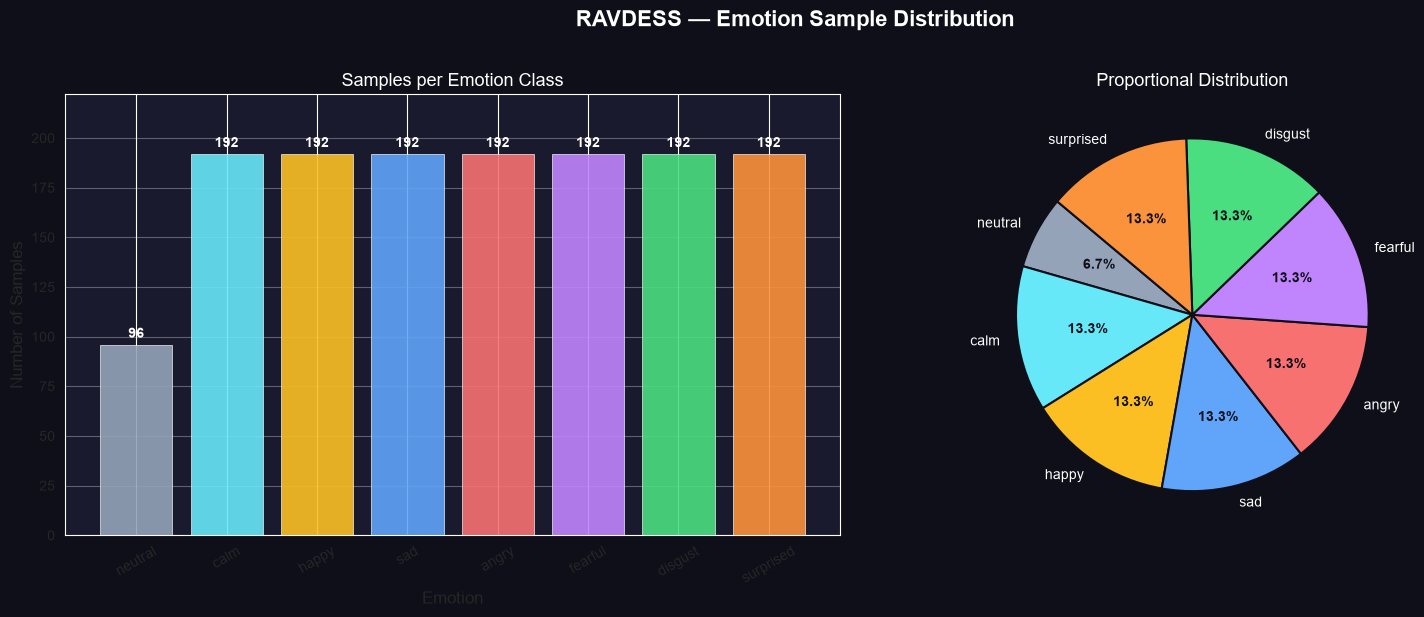

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\emotion_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('RAVDESS — Emotion Sample Distribution', fontsize=16,
             fontweight='bold', color='white', y=1.02)

# ── Bar chart ────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
emotions = emotion_counts.index.tolist()
counts   = emotion_counts.values
colors   = [EMOTION_COLORS[e] for e in emotions]

bars = ax1.bar(emotions, counts, color=colors, edgecolor='white',
               linewidth=0.5, alpha=0.9, zorder=3)
ax1.set_xlabel('Emotion', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Samples per Emotion Class', fontsize=13, color='white')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.set_ylim(0, max(counts) + 30)

for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontsize=10,
             color='white', fontweight='bold')

# ── Pie chart ─────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0f0f1a')
wedges, texts, autotexts = ax2.pie(
    counts, labels=emotions, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 10}
)
for at in autotexts:
    at.set_color('#0f0f1a')
    at.set_fontweight('bold')
ax2.set_title('Proportional Distribution', fontsize=13, color='white')

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'emotion_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 3.8 — Gender × Emotion Breakdown

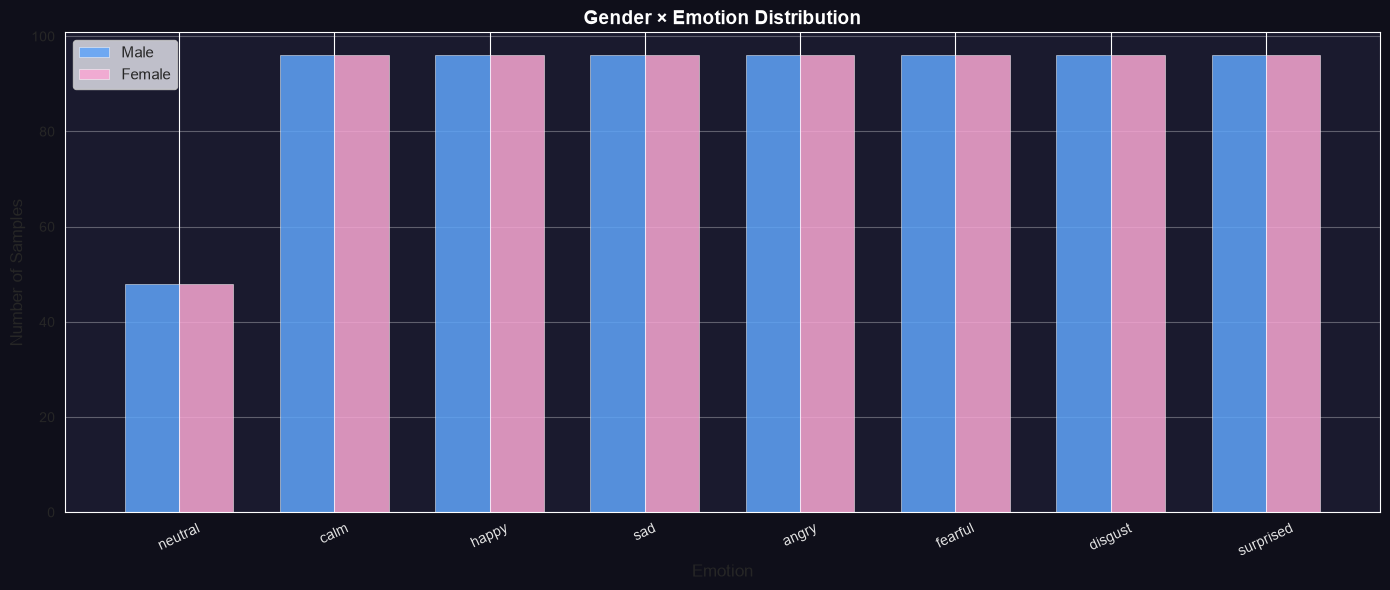

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\gender_emotion_distribution.png

📊 Gender × Emotion Table:
gender     female  male
emotion                
neutral        48    48
calm           96    96
happy          96    96
sad            96    96
angry          96    96
fearful        96    96
disgust        96    96
surprised      96    96


In [8]:
gender_emotion = df_speech.groupby(['emotion', 'gender']).size().unstack(fill_value=0)
gender_emotion = gender_emotion.reindex(list(EMOTION_MAP.values()))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

x     = np.arange(len(gender_emotion.index))
width = 0.35
bars_m = ax.bar(x - width/2, gender_emotion.get('male', 0),
                width, label='Male', color='#60a5fa', alpha=0.85, edgecolor='white', linewidth=0.4)
bars_f = ax.bar(x + width/2, gender_emotion.get('female', 0),
                width, label='Female', color='#f9a8d4', alpha=0.85, edgecolor='white', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(gender_emotion.index, rotation=25, color='#e0e0e0')
ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Gender × Emotion Distribution', fontsize=14,
             fontweight='bold', color='white')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'gender_emotion_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

print('\n📊 Gender × Emotion Table:')
print(gender_emotion)

## 3.9 — Compute Audio Duration Statistics

In [9]:
import soundfile as sf

print('⏱️  Computing durations for all files (this may take ~30s)...')

durations = []
for fp in df_speech['filepath']:
    info = sf.info(fp)
    durations.append(round(info.duration, 3))

df_speech = df_speech.copy()
df_speech['duration_sec'] = durations

print('\n⏱️  Duration Statistics (seconds):')
print('─' * 40)
stats = df_speech['duration_sec'].describe()
for k, v in stats.items():
    print(f'  {k:<6} : {v:.3f} sec')
print('─' * 40)

# Per-emotion mean duration
print('\n⏱️  Mean Duration per Emotion:')
dur_by_emotion = df_speech.groupby('emotion')['duration_sec'].mean().reindex(
    list(EMOTION_MAP.values())
)
for emotion, dur in dur_by_emotion.items():
    print(f'  {emotion:<10} : {dur:.2f} sec')

⏱️  Computing durations for all files (this may take ~30s)...



⏱️  Duration Statistics (seconds):
────────────────────────────────────────
  count  : 1440.000 sec
  mean   : 3.701 sec
  std    : 0.337 sec
  min    : 2.936 sec
  25%    : 3.470 sec
  50%    : 3.670 sec
  75%    : 3.871 sec
  max    : 5.272 sec
────────────────────────────────────────

⏱️  Mean Duration per Emotion:
  neutral    : 3.50 sec
  calm       : 3.80 sec
  happy      : 3.64 sec
  sad        : 3.69 sec
  angry      : 3.87 sec
  fearful    : 3.57 sec
  disgust    : 3.94 sec
  surprised  : 3.49 sec


## 3.10 — Duration Distribution Visualisation

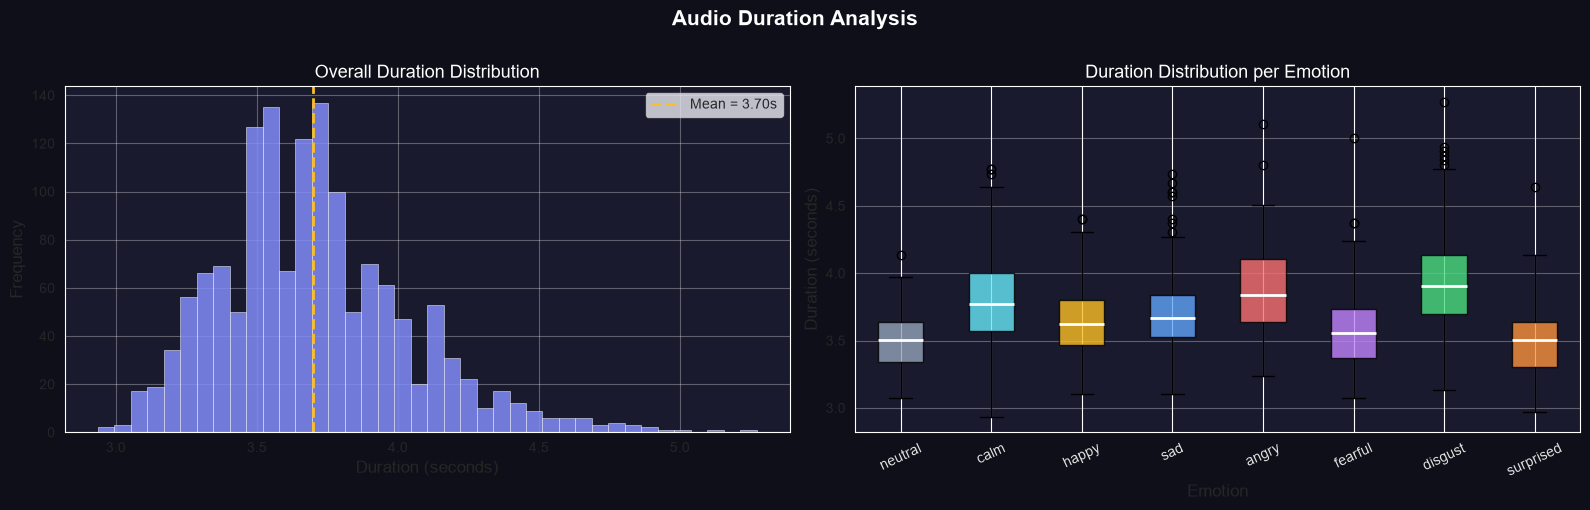

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\duration_analysis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Audio Duration Analysis', fontsize=15, fontweight='bold',
             color='white', y=1.01)

# ── Histogram of durations ───────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.hist(df_speech['duration_sec'], bins=40, color='#818cf8',
         edgecolor='white', linewidth=0.4, alpha=0.85)
ax1.axvline(df_speech['duration_sec'].mean(), color='#fbbf24',
            linestyle='--', linewidth=2, label=f'Mean = {df_speech["duration_sec"].mean():.2f}s')
ax1.set_xlabel('Duration (seconds)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Overall Duration Distribution', fontsize=13, color='white')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# ── Box plot per emotion ──────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
emotion_order = list(EMOTION_MAP.values())
data_by_emotion = [
    df_speech[df_speech['emotion'] == e]['duration_sec'].values
    for e in emotion_order
]
bp = ax2.boxplot(data_by_emotion, patch_artist=True, notch=False,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, emotion in zip(bp['boxes'], emotion_order):
    patch.set_facecolor(EMOTION_COLORS[emotion])
    patch.set_alpha(0.8)
ax2.set_xticks(range(1, len(emotion_order) + 1))
ax2.set_xticklabels(emotion_order, rotation=25, color='#e0e0e0')
ax2.set_xlabel('Emotion', fontsize=12)
ax2.set_ylabel('Duration (seconds)', fontsize=12)
ax2.set_title('Duration Distribution per Emotion', fontsize=13, color='white')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'duration_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 3.11 — Save the Structured Dataset CSV

In [11]:
# Save master metadata CSV
csv_path = os.path.join(FEATURES_DIR, 'dataset_metadata.csv')
df_speech.to_csv(csv_path, index=False)

print('✅ Structured dataset saved!')
print(f'   Path    : {csv_path}')
print(f'   Shape   : {df_speech.shape}')
print(f'   Columns : {list(df_speech.columns)}')
print()
print('📋 Final Dataset Preview:')
df_speech[['filename','actor','gender','emotion','intensity','duration_sec']].head(12)

✅ Structured dataset saved!
   Path    : C:\Speech Emotion Recognition\notebooks\..\features\dataset_metadata.csv
   Shape   : (1440, 12)
   Columns : ['filepath', 'filename', 'actor', 'gender', 'emotion_code', 'emotion', 'intensity', 'statement', 'repetition', 'modality', 'vocal_channel', 'duration_sec']

📋 Final Dataset Preview:


,filename,actor,gender,emotion,intensity,duration_sec
0,03-01-01-01-01-01-01.wav,1,male,neutral,normal,3.303
1,03-01-01-01-01-02-01.wav,1,male,neutral,normal,3.337
2,03-01-01-01-02-01-01.wav,1,male,neutral,normal,3.270
3,03-01-01-01-02-02-01.wav,1,male,neutral,normal,3.170
4,03-01-02-01-01-01-01.wav,1,male,calm,normal,3.537
5,03-01-02-01-01-02-01.wav,1,male,calm,normal,3.604
6,03-01-02-01-02-01-01.wav,1,male,calm,normal,3.503
7,03-01-02-01-02-02-01.wav,1,male,calm,normal,3.470
8,03-01-02-02-01-01-01.wav,1,male,calm,strong,3.704
9,03-01-02-02-01-02-01.wav,1,male,calm,strong,4.004


## 3.12 — Module 3 Summary

| Item | Details |
|---|---|
| **Dataset** | RAVDESS — Ryerson Audio-Visual Database |
| **Total Files** | 1,440 audio files |
| **Speech Files** | 1,440 (all speech modality) |
| **Emotions** | 8 (neutral, calm, happy, sad, angry, fearful, disgust, surprised) |
| **Actors** | 24 (12 male, 12 female) |
| **Format** | WAV, 16-bit PCM, 48,000 Hz |
| **Label Encoding** | Extracted from filename (position 3) |
| **Saved CSV** | `features/dataset_metadata.csv` |

✅ **Module 3 Complete — Ready for Module 4: Audio Data Preprocessing**